In [1]:
import os
import json
import time
import argparse
from typing import Tuple, Optional
import re

import numpy as np
from scipy.optimize import minimize

#few and SEF imports
from few.waveform import GenerateEMRIWaveform
from few.waveform.waveform import SuperKludgeWaveform

from few.trajectory.inspiral import EMRIInspiral
from few.trajectory.ode.flux import KerrEccEqFlux
from few.utils.geodesic import get_fundamental_frequencies
from scipy.interpolate import CubicSpline
from scipy.integrate import cumulative_trapezoid
from few.utils.constants import MTSUN_SI

from fastlisaresponse import ResponseWrapper
from lisatools.detector import EqualArmlengthOrbits
from lisatools.sensitivity import get_sensitivity, A1TDISens, E1TDISens, T1TDISens
from stableemrifisher.utils import generate_PSD, inner_product
from stableemrifisher.fisher import StableEMRIFisher
import matplotlib.pyplot as plt

from config_paris import Config, ObjectiveTracker
from misc import *
try:
    import cupy as cp
    xp=cp
except:
    xp=np
    print("CuPy not found, using NumPy instead. For GPU acceleration, please install CuPy.")

from inference import  prepare_true_waveform

startup


# GENERAL RESULTS FOR EMRI CASE:

EMRI PARARMS: theta0: [1000000.0, 10.0, 0.9, 7.5, 0.5, 0.7853981633974483, 1.0, 0.9, 0.4]
SNR : **56.117062890601325**

## 1 PA best fit points: 
	
	initial_overlap (at True point): 56.11987144384806
	final_overlap: 56.18000175447623
	x_best_fit =  [999945.0911985775, 9.999518520419182, 0.8999715477766329, 7.500185509230793, 0.5000138244123525, 0.7852926441680391, 1.0126540025138149, 1.0750764595107094, 0.3830865238639641]

## 0 PA best fit (BF) points: 


initial_overlap (at True Points): 34.7905807899
	Overlap of the best point: 56.1812841358903
	Best point :  [1000130.6593448946, 10.000806148709128, 0.9000906770429592, 7.499464529275258, 0.4999825121250618, 0.7826067148304708, 1.0111190574872855, 1.057811256605332, 0.3844816292257905]






## PN Informed BF points
	
	intial overlap will be same as 0pa best fit case
	final overlap: 56.182946240232894
	x_best_fit = [1000008.8232475417, 9.999571552108547, 0.9000238821231858, 7.499888382688533, 0.500008994502528, 0.7807665326272081, 1.0127748551659106, 1.092204513244811, 0.3880586212252709, 2.4076903823412796, -2.5709170953033844]


[INFO] Finished loading modules and building ResponseWrapper
[INFO] Finished generating true waveform
shape check - waveform_true: (3, 3155814) PSD_funcs: (3, 1577907)
[TRUE] SNR: 56.117063
[TRUE] SNR - Channel 0: 29.274638
[TRUE] SNR - Channel 1: 24.652424
[TRUE] SNR - Channel 2: 41.041178
[INFO] Frequency resolution delta_f: 3.168755e-08 Hz, Number of frequency bins: 1577908
freq_max: 0.050000 Hz and Freq_min: 0.000000 Hz


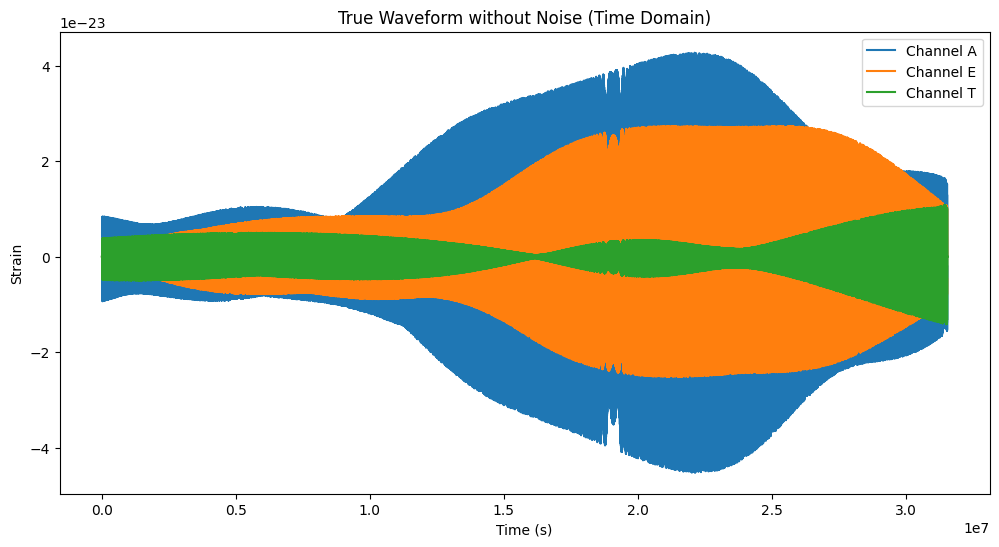

[INFO] Added noise to true waveform FFT

shape of waveform_true_fft after noise addition: (3, 1577907)


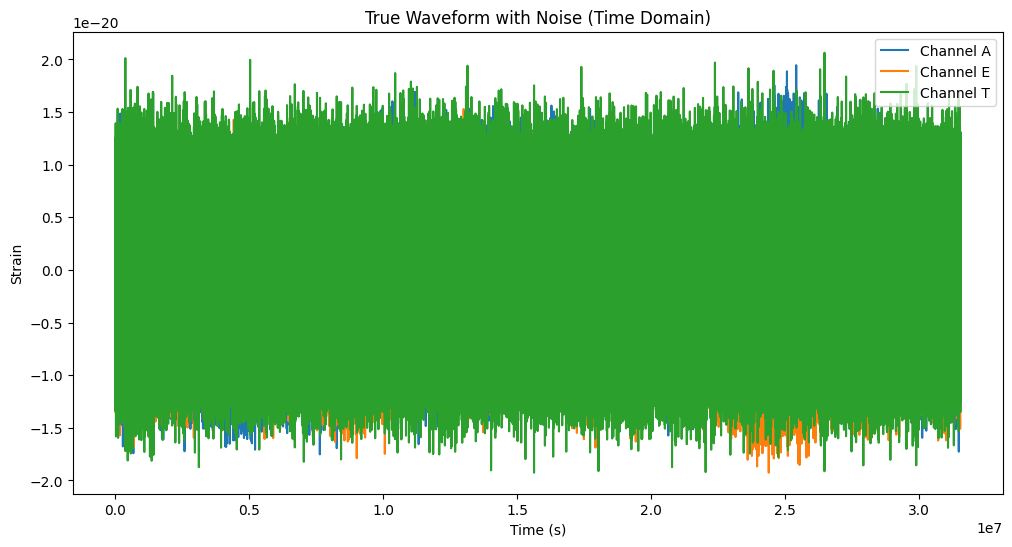

Length of PSD: 1577907


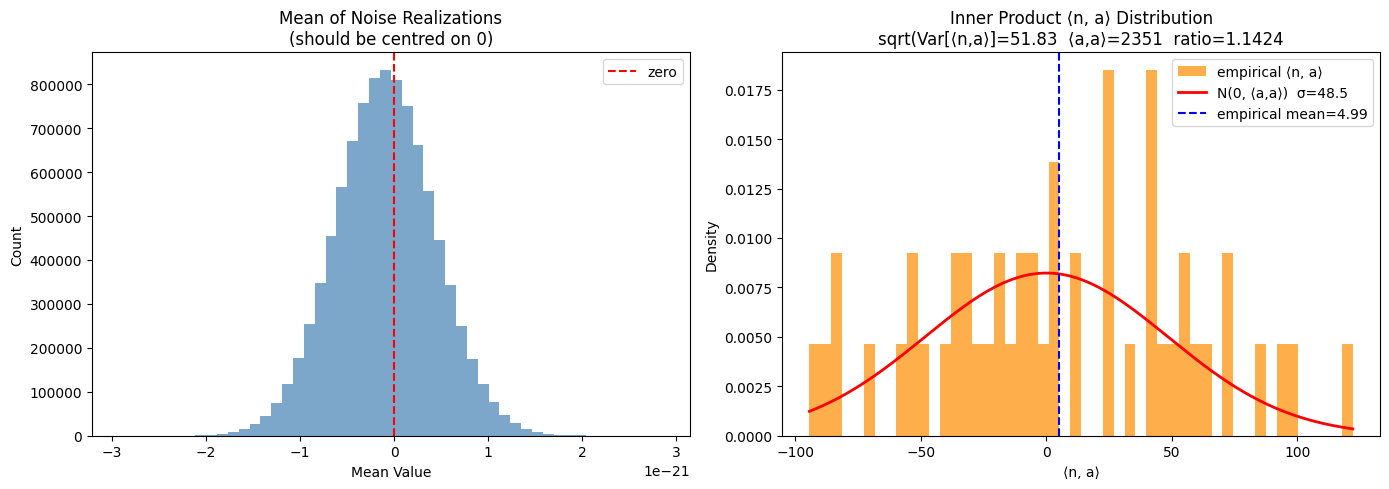

  Noise model consistency check
  Backend                : CuPy (GPU)
  Realizations           : 50
  N time samples         : 3155812  |  PSD bins passed: 1577906
  N (template samples)   : 3155814  →  aligned to 3155812
  Max |mean noise|       : 2.9210e-21  (expect ≈ 0)
  E[⟨n, a⟩]             : 4.9898e+00           (expect ≈ 0)
  Var[⟨n, a⟩]           : 2686.24
  ⟨a, a⟩                : 2351.33
  Ratio Var/⟨a,a⟩       : 1.142438          (expect ≈ 1.0)
Noise consistency check results: {'mean_noise': array([[-1.18794595e-21,  1.36232892e-22, -6.15643676e-22, ...,
        -4.44976478e-22,  5.26117858e-23, -8.67820743e-24],
       [-5.26450328e-22, -7.61148346e-22,  1.87398330e-22, ...,
        -4.25873893e-22, -5.13896866e-22, -8.15622480e-23],
       [-5.94128647e-22, -1.61072590e-22,  5.37821704e-22, ...,
         1.74171193e-22, -1.09600006e-21,  1.25377293e-21]],
      shape=(3, 3155812)), 'inner_products': array([ 56.50327042, -54.86381078,  25.23093475, -55.9357626 ,
       -30

{'m1': np.float64(1000000.0),
 'm2': np.float64(10.0),
 'a': np.float64(0.9),
 'p0': np.float64(7.5),
 'e0': np.float64(0.5),
 'Y0': np.float64(1.0),
 'dist': np.float64(5.0),
 'qS': np.float64(0.7853981633974483),
 'phiS': np.float64(1.0),
 'qK': np.float64(1.0),
 'phiK': np.float64(1.0471975511965976),
 'Phi_phi0': np.float64(0.9),
 'Phi_theta0': np.float64(0.5),
 'Phi_r0': np.float64(0.4),
 'dt': 10,
 'T': 1.0,
 'chi2': 0.0,
 'dev_1': 0.0,
 'dev_2': 0.0,
 'waveform_response': <fastlisaresponse.response.ResponseWrapper at 0x1554c9dd3200>,
 'PSD_funcs': array([[6.81763434e-35, 1.70440862e-35, 7.57514968e-36, ...,
         1.61311193e-40, 1.61310358e-40, 1.61309523e-40],
        [6.81763434e-35, 1.70440862e-35, 7.57514968e-36, ...,
         1.61311193e-40, 1.61310358e-40, 1.61309523e-40],
        [2.65994853e-56, 1.06395802e-55, 2.39388950e-55, ...,
         5.36070468e-40, 5.36068302e-40, 5.36066135e-40]],
       shape=(3, 1577907)),
 'waveform_true_fft': array([[-6.25689817e-15-2.560

In [2]:
seed= 42   
param_names_to_infer = ['m1', 'm2', 'a', 'p0', 'e0', 'qS', 'phiS', 'Phi_phi0', 'Phi_r0']  
params_name = ["m1","m2","a","p0","e0","xI0","dist","qS","phiS","qK","phiK",
                         "Phi_phi0","Phi_theta0","Phi_r0"]      

params = np.array([1e6,1e1,0.9, 7.5,  5.00000000e-01,  1.00000000e+00,
          5.0,  np.pi/4,  1.0, 1,  np.pi/3,  9.00000000e-01, 5.00000000e-01,  4.00000000e-01])

signal_param = {"m1": 1e6,
    "m2": 10.0,
    "a": 0.9,
    "p0": 7.5,
    "e0": 0.5,
    "xI0": 1.0,
    "dist": 5.0,
    "qS": np.pi/4,
    "phiS": 1,
    "qK": 1,
    "phiK": np.pi/3,
    "Phi_phi0": 0.9,
    "Phi_theta0": 0.5,
    "Phi_r0": 4.00000000e-01,
}
signal_param_array = np.array(list(signal_param.values()))
dt = 10  #Time step for waveform generation; default 0.1s
T= 1.0

chi2 = 0.0 
dev_1 = 0.0
dev_2 = 0.0

emri_kwargs = {"T": T, "dt": dt,'chi2': chi2,'evolve_1PA': True,'evolve_primary': False,'evolve_2PA': False,'deviation_included': True,
                   'dev_1': dev_1, 'dev_2': dev_2}
add_kwargs = {'chi2': chi2,'evolve_1PA': True,'evolve_primary': False,'evolve_2PA': False,'deviation_included': True,
                   'dev_1': dev_1, 'dev_2': dev_2}

# if target_func in ('optimal_snr', 'optimal_snr_phase_max','time_max'):
        
ctx = prepare_true_waveform(signal_param_array, emri_kwargs, add_kwargs,add_noise=True, use_gpu=True,seed=seed)

snr_2 = inner_prod(ctx['waveform_true_fft_without_noise'], ctx['waveform_true_fft_without_noise'], ctx['PSD_funcs'], ctx['delta_f'], xp=xp)
ctx

# Overlap with Noise and With True Signal Without Noise

In [3]:
noise_f =  ctx['noise']
Respsone = ctx['waveform_response']


## 1PA best fit

In [4]:
x_best_fit_1PA =  [999945.0911985775, 9.999518520419182, 0.8999715477766329, 7.500185509230793,
                    0.5000138244123525, 0.7852926441680391, 1.0126540025138149, 1.0750764595107094, 0.3830865238639641]
add_kwargs = {'chi2': 0,'evolve_1PA': True,'evolve_primary': False,'evolve_2PA': False,'deviation_included': True,
                   'dev_1': 0, 'dev_2': 0}

m1, m2, a, p0, e0,qS,phiS,Phi_phi0,Phi_r0 = x_best_fit_1PA
wave_params = [m1, m2, a, p0, e0, ctx['Y0'],ctx['dist'],qS,phiS, ctx['qK'], ctx['phiK'], 
                    Phi_phi0, ctx['Phi_theta0'], Phi_r0,add_kwargs['chi2'],add_kwargs['evolve_1PA'],add_kwargs['evolve_primary'],
                    add_kwargs['evolve_2PA'], add_kwargs['deviation_included'],add_kwargs['dev_1'],add_kwargs['dev_2']]
emri_kwargs =  {"T": ctx['T'], "dt": ctx['dt'],'chi2': add_kwargs['chi2'],'evolve_1PA': add_kwargs['evolve_1PA'],
                    'evolve_primary': add_kwargs['evolve_primary'],'evolve_2PA': add_kwargs['evolve_2PA'],'deviation_included': add_kwargs['deviation_included'],
               'dev_1': add_kwargs['dev_1'], 'dev_2': add_kwargs['dev_2']}
h_1PA = xp.array(Respsone(*wave_params, **emri_kwargs))
h_1PA_f = compute_fft_with_windowing(h_1PA, ctx['dt'], ctx['N_fiducial'],type=None,use_gpu=True,n_channels=3)
n_hf = inner_prod(h_1PA_f, noise_f, ctx['PSD_funcs'], ctx['delta_f'], xp=xp)
print("noise inner product with 1PA:", n_hf)
optimal_snr_h_1PA = inner_prod(h_1PA_f, h_1PA_f, ctx['PSD_funcs'], ctx['delta_f'], xp=xp
                               )
print("detection SNR", n_hf/np.sqrt(optimal_snr_h_1PA))

actual_overlap = inner_prod(ctx['waveform_true_fft_without_noise'], h_1PA_f, ctx['PSD_funcs'], ctx['delta_f'], xp=xp)
print("Actual overlap:", np.sqrt(actual_overlap))
print("detection SNR using true waveform:", actual_overlap/np.sqrt(optimal_snr_h_1PA))

noise inner product with 1PA: 6.701665862924128
detection SNR 0.12183623839603731
Actual overlap: 55.52934938778507
detection SNR using true waveform: 56.05816551608019


## 0PA best fit

In [5]:
x_best_fit_0PA =  [1000130.6593448946, 10.000806148709128, 0.9000906770429592, 7.499464529275258, 0.4999825121250618,
                    0.7826067148304708, 1.0111190574872855, 1.057811256605332, 0.3844816292257905]
add_kwargs = {'chi2': 0,'evolve_1PA': False,'evolve_primary': False,'evolve_2PA': False,'deviation_included': True,
                   'dev_1': 0, 'dev_2': 0}

m1, m2, a, p0, e0,qS,phiS,Phi_phi0,Phi_r0 = x_best_fit_0PA
wave_params = [m1, m2, a, p0, e0, ctx['Y0'],ctx['dist'],qS,phiS, ctx['qK'], ctx['phiK'], 
                    Phi_phi0, ctx['Phi_theta0'], Phi_r0,add_kwargs['chi2'],add_kwargs['evolve_1PA'],add_kwargs['evolve_primary'],
                    add_kwargs['evolve_2PA'], add_kwargs['deviation_included'],add_kwargs['dev_1'],add_kwargs['dev_2']]

emri_kwargs =  {"T": ctx['T'], "dt": ctx['dt'],'chi2': add_kwargs['chi2'],'evolve_1PA': add_kwargs['evolve_1PA'],
                    'evolve_primary': add_kwargs['evolve_primary'],'evolve_2PA': add_kwargs['evolve_2PA'],'deviation_included': add_kwargs['deviation_included'],
               'dev_1': add_kwargs['dev_1'], 'dev_2': add_kwargs['dev_2']}

h_0PA = xp.array(Respsone(*wave_params, **emri_kwargs))
h_0PA_f = compute_fft_with_windowing(h_0PA, ctx['dt'], ctx['N_fiducial'],type=None,use_gpu=True,n_channels=3)
n_hf = inner_prod(h_0PA_f, noise_f, ctx['PSD_funcs'], ctx['delta_f'], xp=xp)
print("noise inner product with 0PA:", n_hf)
optimal_snr_h_0PA = inner_prod(h_0PA_f, h_0PA_f, ctx['PSD_funcs'], ctx['delta_f'], xp=xp
                               )
print("detection SNR", n_hf/np.sqrt(optimal_snr_h_0PA))

actual_overlap = inner_prod(ctx['waveform_true_fft_without_noise'], h_0PA_f, ctx['PSD_funcs'], ctx['delta_f'], xp=xp)
print("Actual overlap:", np.sqrt(actual_overlap))
print("detection SNR using true waveform:", actual_overlap/np.sqrt(optimal_snr_h_0PA))

noise inner product with 0PA: 6.69897324644285
detection SNR 0.1218629941523129
Actual overlap: 55.5127195702828
detection SNR using true waveform: 56.059421141737964


# 0PA + dev

In [8]:
x_best_fit_0PA_dev =  [1000008.8232475417, 9.999571552108547, 0.9000238821231858, 
                       7.499888382688533, 0.500008994502528, 0.7807665326272081,
                        1.0127748551659106, 1.092204513244811, 0.3880586212252709,
                          2.4076903823412796, -2.5709170953033844]


add_kwargs = {'chi2': 0,'evolve_1PA': False,'evolve_primary': False,'evolve_2PA': False,'deviation_included': True,
                   'dev_1': x_best_fit_0PA_dev[-2], 'dev_2': x_best_fit_0PA_dev[-1]}

m1, m2, a, p0, e0,qS,phiS,Phi_phi0,Phi_r0,dev_1,dev_2 = x_best_fit_0PA_dev

wave_params = [m1, m2, a, p0, e0, ctx['Y0'],ctx['dist'],qS,phiS, ctx['qK'], ctx['phiK'], 
                    Phi_phi0, ctx['Phi_theta0'], Phi_r0,add_kwargs['chi2'],add_kwargs['evolve_1PA'],add_kwargs['evolve_primary'],
                    add_kwargs['evolve_2PA'], add_kwargs['deviation_included'],add_kwargs['dev_1'],add_kwargs['dev_2']]

emri_kwargs =  {"T": ctx['T'], "dt": ctx['dt'],'chi2': add_kwargs['chi2'],'evolve_1PA': add_kwargs['evolve_1PA'],
                    'evolve_primary': add_kwargs['evolve_primary'],'evolve_2PA': add_kwargs['evolve_2PA'],'deviation_included': add_kwargs['deviation_included'],
               'dev_1': add_kwargs['dev_1'], 'dev_2': add_kwargs['dev_2']}

h_0PA_dev = xp.array(Respsone(*wave_params, **emri_kwargs))
h_0PA_dev_f = compute_fft_with_windowing(h_0PA_dev, ctx['dt'], ctx['N_fiducial'],type=None,use_gpu=True,n_channels=3)
n_hf_dev = inner_prod(h_0PA_dev_f, noise_f, ctx['PSD_funcs'], ctx['delta_f'], xp=xp)
print("noise inner product with 0PA:", n_hf_dev)
optimal_snr_h_0PA_dev = inner_prod(h_0PA_dev_f, h_0PA_dev_f, ctx['PSD_funcs'], ctx['delta_f'], xp=xp
                               )
print("detection SNR", n_hf_dev/np.sqrt(optimal_snr_h_0PA_dev))

actual_overlap = inner_prod(ctx['waveform_true_fft_without_noise'], h_0PA_dev_f, ctx['PSD_funcs'], ctx['delta_f'], xp=xp)
print("Actual overlap:", np.sqrt(actual_overlap))
print("detection SNR using true waveform:", actual_overlap/np.sqrt(optimal_snr_h_0PA_dev))

noise inner product with 0PA: 6.955298091511008
detection SNR 0.1265732569413979
Actual overlap: 55.50081918511671
detection SNR using true waveform: 56.05637298329149


# CV Bias For noise